In [1]:
import cv2
import numpy as np

In [2]:
# 4 - Perform[image negation, log transformation, gamma transformation, piecewise-linear transformation] using both built-in and custom function. 

def cv2_cleanup():
    cv2.waitKey()
    cv2.destroyAllWindows()

img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)
cv2.imshow("Image", img)
cv2_cleanup()

In [3]:
# Image Negation

built_negate = cv2.bitwise_not(img)
cv2.imshow("Builtin - Image Negation", built_negate)

custom_negate = 255 - img
cv2.imshow("Custom - Image Negation", custom_negate)
cv2_cleanup()

In [4]:
# Log Transformation

img_float = img.astype(np.float32)
c = 255 / np.max(1 + np.log(img_float))

built_log = c * cv2.log(1 + img_float)
built_log = np.uint8( np.clip(built_log, 0, 255) )
cv2.imshow("Builtin - Log Transformation", built_log)

custom_log = c * np.log(1 + img_float)
custom_log = np.uint8( np.clip(custom_log, 0, 255))
cv2.imshow("Custom - Log Transformation", custom_log)
cv2_cleanup()

In [5]:
# Gamma Transformation

bright_gamma = 0.5
dark_gamma = 1.5

# c = 255 & normalized before using function
built_bg = cv2.LUT(img, np.array([ ((i / 255)  ** bright_gamma) * 255 for i in np.arange(256) ], dtype=np.uint8))
built_dg = cv2.LUT(img, np.array([ ((i / 255)  ** dark_gamma) * 255 for i in np.arange(256) ], dtype=np.uint8))
cv2.imshow("Builtin - Brighter Gamma", built_bg)
cv2.imshow("Builtin - Darker Gamma", built_dg)
cv2_cleanup()

custom_bg = np.uint8(((img / 255) ** bright_gamma) * 255)
custom_dg = np.uint8(((img / 255) ** dark_gamma) * 255)
cv2.imshow("Custom - Brighter Gamma", custom_bg)
cv2.imshow("Custom - Darker Gamma", custom_dg)
cv2_cleanup()

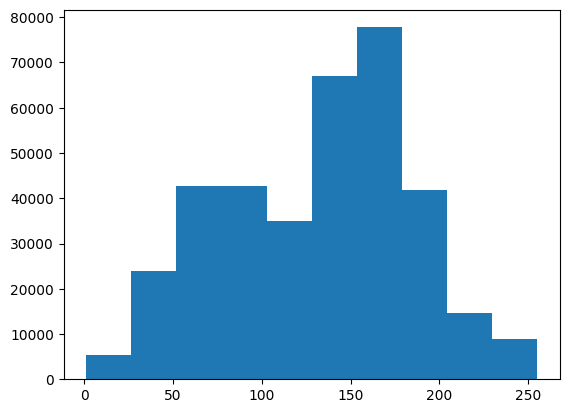

In [6]:
# Image Analysis

import matplotlib.pyplot as plt
plt.hist(img.flatten())
plt.show()

# Based on Image Analysis, Image mostly spread in 35 - 200 range so converting it into 10 - 240
s1, s2 = 35, 200
r1, r2 = 10, 240

In [8]:
# Spreading range for the image values from (s1, s2) to (r1, r2)
lut = np.zeros(256, dtype=np.uint8)

for r in range(256):

    if r < s1:
        lut[r] = (s1 / r1) * r
    elif r < s2:
        # s2 - s1 / r2 - r1 => works like alpha range for conversion
        lut[r] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
    else:
        lut[r] = ((255 - s1) / (255 - r1)) * (r - r2) + s2 

built_pclt = cv2.LUT(img, lut)
cv2.imshow("Builtin - Piecewise Linear Transformation", built_pclt)

custom_pclt = img.copy()
height, width = img.shape
for h in range(height):
    for w in range(width):
        custom_pclt[h, w] = lut[img[h, w]]

cv2.imshow("Custom - Piecewise Linear Transformation", custom_pclt)
cv2_cleanup()